# 10 · 토스 선택형 지역 안내 실험 — 계측 준비도 G1

**한 줄 질문:** 현재 로그로 ‘어느 지역을 권했는가 → 눌렀는가 → 그 지역에서 첫 행동을 했는가’를 재구성할 수 있나?

사용자가 승인한 G0 후보: **선택형 지역 안내가 기존 배너보다 미경험 지역의 첫 행동 도달을 높인다.** 이 노트북은 효과를 검정하지 않는다. 새 안내가 아직 없으므로 G1에서 현재 계측의 신뢰성만 판단한다.

**사전 통과 기준:** 배너 노출마다 추천 ID와 대상 지역이 기록되고, 클릭·도착 이벤트가 같은 ID로 연결되며, 대조군 배정 단위가 확인되면 통과. 하나라도 없으면 효과 측정 불가로 제한부/미통과 판정하고 다음 계측 항목을 적는다. 결과를 보고 기준을 고치지 않는다.

## 1. 범위와 제외

- BigQuery GA4의 완전 일별 export 2026-09-04~09-12(KST), `event_params.platform='toss'`가 붙은 이벤트만 본다. `(direct)` 유입 소스는 토스 판정에 쓰지 않는다.
- 기록된 `beta_A/B` 표식 행은 제외한다. 이전 감사에서 토스 행의 베타 표식은 0건이었다. 미표식 내부 사용자는 남을 수 있다.
- `login`·자동 GA4 이벤트·일반 게임 행동을 **배너 노출**로 세지 않는다. `zone_enter`는 일부 지역에서만 나오는 위치 기록이므로 추천 도착과 동일시하지 않는다.
- `shown=true`는 배너 표시를 기록했다는 뜻이다. 실제로 화면에서 읽었는지, 소리가 재생돼 들렸는지는 확인할 수 없다.
- 분석 대상은 기기/브라우저 `user_pseudo_id` 기준이다. 사람 수가 아니다.

In [1]:
from pathlib import Path
import os,sys
import pandas as pd
from IPython.display import Markdown,display

ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0,str(ROOT/'ml'))
from calm_ml import bq,report as R
R.setup()
AUDIT_SQL=ROOT/'ml/sql/g1_toss_guidance_measurement_audit.sql'
SHOWN_SQL=ROOT/'ml/sql/g1_toss_guidance_shown_devices.sql'
OUT=ROOT/'ml/reports/g1_toss_guidance_readiness_2026-09-14'
OUT.mkdir(parents=True,exist_ok=True)
print('SQL 원본:',AUDIT_SQL,SHOWN_SQL)


SQL 원본: /Users/uicheol_hwang/calm_forest/ml/sql/g1_toss_guidance_measurement_audit.sql /Users/uicheol_hwang/calm_forest/ml/sql/g1_toss_guidance_shown_devices.sql


## 2. 실행 SQL과 원시 집계

두 쿼리는 이벤트 이름·파라미터별 기록 건수와, 중복 점수 이벤트를 제거한 기기 수를 확인한다. 원시 식별자는 SQL 안의 `COUNT(DISTINCT ...)`에만 쓰고 결과에 남기지 않는다.

In [2]:
display(Markdown('```sql\n'+AUDIT_SQL.read_text(encoding='utf-8')+'\n```'))
display(Markdown('```sql\n'+SHOWN_SQL.read_text(encoding='utf-8')+'\n```'))
audit=bq.read_sql_file(str(AUDIT_SQL))
shown=bq.read_sql_file(str(SHOWN_SQL))
audit.to_csv(OUT/'event_parameter_coverage.csv',index=False)
shown.to_csv(OUT/'scored_shown_devices.csv',index=False)
display(audit)
display(shown)


```sql
-- G1: can existing Toss GA4 logs measure an optional area recommendation?
-- Toss = event parameter platform='toss', not acquisition source.
-- Window: complete GA4 daily exports 2026-09-04..09-12 KST.
-- Exclude beta_A/B-marked rows; prior audit found zero marked Toss rows.
-- Only aggregate event/parameter coverage; no identifiers leave the query.
WITH base AS (
  SELECT
    user_pseudo_id,
    event_name,
    event_params,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS platform,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND user_pseudo_id IS NOT NULL
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-12'
),
toss AS (
  SELECT * FROM base
  WHERE platform = 'toss'
    AND NOT REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')
),
relevant AS (
  SELECT
    user_pseudo_id,
    event_name,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'arm' LIMIT 1) AS arm,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'trigger' LIMIT 1) AS trigger_kind,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'skipped' LIMIT 1) AS skipped,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'cue' LIMIT 1) AS cue,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'target_area' LIMIT 1) AS target_area,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'recommendation_id' LIMIT 1) AS recommendation_id,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'zone' LIMIT 1) AS zone,
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'shown' LIMIT 1) AS shown_int,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'shown' LIMIT 1) AS shown_string
  FROM toss
  WHERE event_name IN (
    'churn_score', 'hint_banner_show', 'hint_banner_click',
    'recommendation_shown', 'recommendation_click', 'recommendation_arrive',
    'zone_enter', 'map_opened', 'map_locked', 'guide_open'
  )
)
SELECT
  event_name,
  COUNT(*) AS event_rows,
  COUNT(DISTINCT user_pseudo_id) AS devices,
  COUNTIF(arm = 'treat') AS treat_rows,
  COUNTIF(arm = 'control') AS control_rows,
  COUNTIF(trigger_kind IS NOT NULL) AS trigger_rows,
  COUNTIF(skipped IS NOT NULL) AS skipped_rows,
  COUNTIF(cue IS NOT NULL) AS cue_rows,
  COUNTIF(COALESCE(shown_int, IF(shown_string = 'true', 1, 0)) = 1) AS shown_rows,
  COUNTIF(target_area IS NOT NULL) AS target_area_rows,
  COUNTIF(recommendation_id IS NOT NULL) AS recommendation_id_rows,
  COUNTIF(zone IS NOT NULL) AS zone_rows
FROM relevant
GROUP BY event_name
ORDER BY event_rows DESC, event_name;

```

```sql
-- G1 follow-up: distinct Toss devices with scored/shown churn banners.
-- Same window and platform/beta filters as measurement audit.
WITH score_events AS (
  SELECT
    user_pseudo_id,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='arm' LIMIT 1) AS arm,
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep
      WHERE ep.key='shown' LIMIT 1) AS shown_int,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='shown' LIMIT 1) AS shown_string
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND event_name='churn_score'
    AND user_pseudo_id IS NOT NULL
    AND DATE(TIMESTAMP_MICROS(event_timestamp),'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-12'
    AND (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='platform' LIMIT 1)='toss'
    AND NOT REGEXP_CONTAINS(COALESCE((
      SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key='ab_variant' LIMIT 1),''),r'^beta_[AB]$')
)
SELECT
  arm,
  COUNT(*) AS score_rows,
  COUNT(DISTINCT user_pseudo_id) AS scored_devices,
  COUNTIF(COALESCE(shown_int,IF(LOWER(shown_string)='true',1,0))=1) AS shown_rows,
  COUNT(DISTINCT IF(COALESCE(shown_int,IF(LOWER(shown_string)='true',1,0))=1,
      user_pseudo_id,NULL)) AS shown_devices
FROM score_events
GROUP BY arm
ORDER BY arm;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_name,event_rows,devices,treat_rows,control_rows,trigger_rows,skipped_rows,cue_rows,shown_rows,target_area_rows,recommendation_id_rows,zone_rows
0,zone_enter,257,10,0,0,0,0,0,0,0,0,257
1,churn_score,217,15,115,102,217,12,15,15,0,0,0
2,guide_open,2,2,0,0,0,0,0,0,0,0,0


,arm,score_rows,scored_devices,shown_rows,shown_devices
0,control,102,8,0,0
1,treat,115,9,15,6


## 3. 어디까지 잴 수 있나

아래 막대는 **기록으로 확인 가능한 기기 수**다. 효과 퍼널이나 실제 사용자 이탈 흐름이 아니다. 추천 지역·클릭·도착이 0인 것은 유저가 아무것도 하지 않았다는 뜻이 아니라 해당 연결 기록이 없다는 뜻이다.

,기록 단계,확인 기기 수
0,이탈 점수 기록,15
1,배너 표시 기록,6
2,추천 지역 표식,0
3,추천 클릭 전용 이벤트,0
4,추천 도착 전용 이벤트,0


g1_toss_guidance_measurement_chain.png  1125x631px


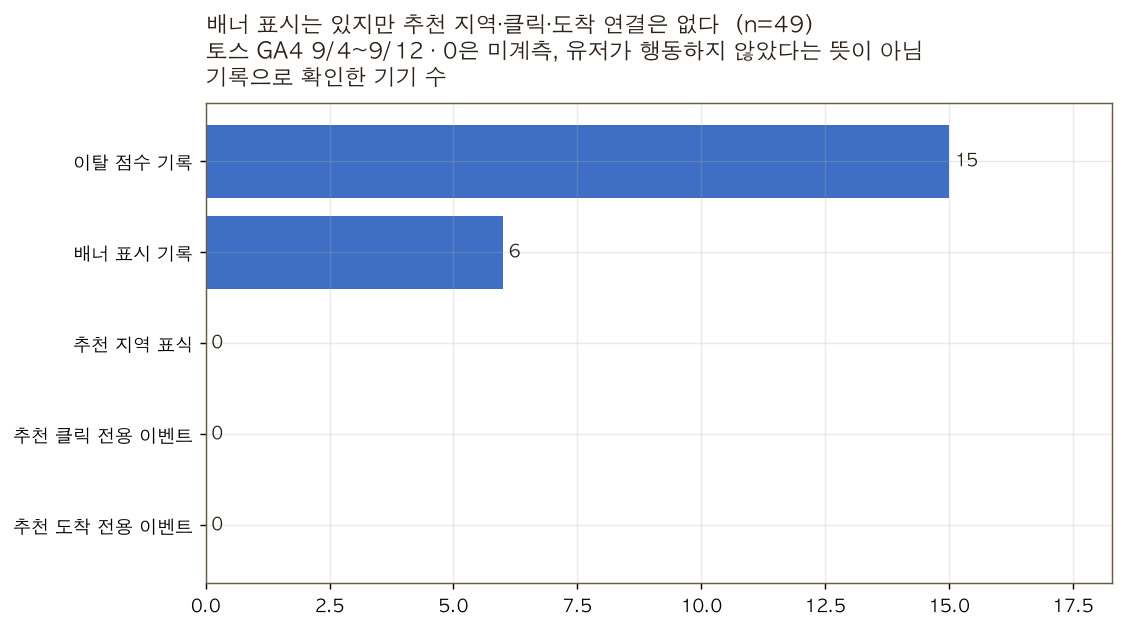

In [3]:
score=audit.set_index('event_name').loc['churn_score']
scored=int(score.devices)
shown_devices=int(shown.shown_devices.sum())
target_tagged=0 if int(score.target_area_rows)==0 else None
click_devices=int(audit.loc[audit.event_name.isin(['hint_banner_click','recommendation_click']),'devices'].sum())
arrival_devices=int(audit.loc[audit.event_name=='recommendation_arrive','devices'].sum())
coverage=pd.DataFrame({
 '기록 단계':['이탈 점수 기록','배너 표시 기록','추천 지역 표식','추천 클릭 전용 이벤트','추천 도착 전용 이벤트'],
 '확인 기기 수':[scored,shown_devices,target_tagged,click_devices,arrival_devices],
})
coverage.to_csv(OUT/'measurement_chain.csv',index=False)
display(coverage)
fig,ax=R.new('배너 표시는 있지만 추천 지역·클릭·도착 연결은 없다',49,
             sub='토스 GA4 9/4~9/12 · 0은 미계측, 유저가 행동하지 않았다는 뜻이 아님',
             ylab='기록으로 확인한 기기 수',figsize=(9,4.8))
bars=ax.barh(coverage['기록 단계'],coverage['확인 기기 수'],color=R.PALETTE[1])
ax.invert_yaxis();ax.bar_label(bars,padding=3)
ax.set_xlim(0,max(coverage['확인 기기 수'])*1.22)
chart=R.save(fig,ax,'g1_toss_guidance_measurement_chain',zero_base=False)
print(R.check(chart));display(R.show(chart))


## 4. 현재 행동 도달은 기준선일 뿐

앞선 08 노트북의 동일 기간 49기기에서 첫 토스 관측일의 영역별 도달은 자연·채집 20대, 퀘스트·교류 20대, 고급 콘텐츠 14대, 제작·집 13대, 낚시·바다 9대였다. 이는 **안내 없이도 관측된 경험률**이다. ‘적게 했다’가 ‘추천받으면 좋아할 것이다’를 뜻하지 않는다. 접근 가능 여부·도구·진행도·노출 기회가 섞여 있기 때문이다. 아래 그림은 기존 분석의 기준선 PNG를 재사용한다.

,영역,도달 기기,전체 대비 비율,95% 하한,95% 상한
0,자연·채집,20,0.408163,0.282150,0.547529
1,낚시·바다,9,0.183673,0.099762,0.313579
2,퀘스트·교류,20,0.408163,0.282150,0.547529
3,제작·집,13,0.265306,0.162111,0.402626
4,고급 콘텐츠,14,0.285714,0.178494,0.424091


g2_toss_area_reach.png  960x571px


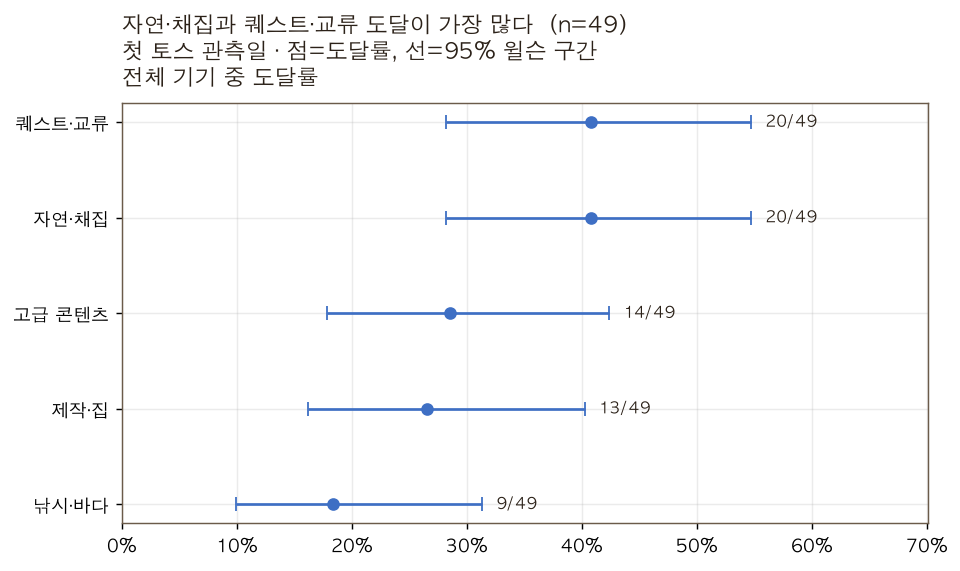

In [4]:
baseline=ROOT/'ml/reports/g2_toss_behavior_2026-09-14/area_reach.csv'
area=pd.read_csv(baseline)
display(area)
baseline_chart=ROOT/'ml/reports/figs/g2_toss_area_reach.png'
print(R.check(baseline_chart));display(R.show(baseline_chart))


## 5. 코드에서 확인한 계측 간극

- `js/predict.js`의 `pickIntervention`은 상태에 따라 배너 문구를 고르지만 선택한 `kind`나 `target_area`를 `churn_score`에 싣지 않는다.
- `js/game.js`의 배너 호출은 `Sound.nudge`와 진동을 요청한다. `churn_score.cue`는 신호를 **요청했다는 기록**이지 실제 재생 성공·청취 기록이 아니다.
- `index.html`의 배너 UI 자체는 `onTap`을 지원하지만, 현재 예측기에서 넘기는 배너에는 `onTap`이 없다. 추천 클릭을 연결할 이벤트도 없다.
- `zone_enter`는 일부 장소 진입에서 발생한다. 모든 추천 영역의 도착을 동일한 방식으로 추적하지 않는다.
- `arm`은 세션마다 정한다. 이번 집계는 treat 9기기·control 8기기지만 고유 점수화 기기는 15대다. **2기기가 다른 세션에서 양쪽에 등장**했으므로 기기별 독립 A/B 표본처럼 비교하면 안 된다.

## 6. 그래서 크기가 얼마나 되나

현재 토스 로그에는 이탈 점수 **217건/15기기**, 배너 표시 **15건/6기기**가 있다. 추천 대상 지역·추천 ID는 **0건**, 클릭·추천 도착 전용 이벤트도 **0건**이다. 따라서 현재 데이터로는 ‘선택형 지역 안내가 첫 행동 도달을 높인다’는 가설을 채택하거나 기각할 수 없다. G1의 사전 통과 기준은 **미통과**다. 지금 모델을 학습하면 목표 라벨이 없는 상태에서 기록량이 많은 소수 기기만 학습할 위험이 크다.

## 7. 이 숫자로 말할 수 없는 것

- `zone_enter` 257건/10기기가 배너 때문에 발생했다고 말할 수 없다. 목표 지역 ID와 추천 ID가 없다.
- 배너 표시 15건은 15명이 아니다. 6기기에서 반복 노출된 것이다.
- `cue` 15건은 알림음이 실제로 들린 횟수가 아니다. 음소거·브라우저 오디오 정책·효과음 설정은 별도로 확인해야 한다.
- treat/control 점수 이벤트 115/102건은 세션·기기별 독립 실험 표본 수가 아니다.
- 기존 지역 도달률은 선택 편향과 잠금/진행도 제약을 포함한다. 낮은 도달률만으로 추천 우선순위를 정할 수 없다.

## 8. 다음에 확인할 것

별도 승인 후 선택형 안내를 구현한다면 **recommendation_id, target_area, eligibility, arm, impression, tap, waypoint/teleport 선택, arrival, target_first_action, dismiss, sound_requested/played**를 같은 추천 건에 연결해 기록해야 한다. 잠금 조건과 기존 퀘스트를 우선하고, 이동은 유저가 눌렀을 때만 가능하게 한다. 이번 G1에서는 구현·모델링을 하지 않고 멈춘다.

## 9. 분석 가정

| 가정 | 근거 | 확신 | 틀렸을 때 영향 | 점검 |
|---|---|---|---|---|
| GA4 `platform=toss`가 토스 웹뷰 이벤트를 식별 | 클라이언트 분석 코드 | 중 | 표본 누락·오분류 | 세션 로그 플랫폼과 재대조 |
| `shown=true`가 배너 표시 요청을 뜻함 | 예측기 코드 | 중 | 실제 노출 과대 | UI 표시 성공 이벤트 분리 |
| `beta_A/B` 표식 없는 토스 이벤트가 일반 유입의 근사치 | 이전 표식 감사 | 중 | 내부 사용자 혼입 | 테스터 명단-기기 매핑 점검 |
| 9/12가 마지막 완전 GA4 일별 export | 이전 감사 | 높음 | 최신 유입 제외 | 9/13 export 후 재실행 |

W&B 업로드는 앞선 안전 검토에서 보류돼 이 노트북은 로컬에만 저장한다.